/tmp/ipykernel_200/1630916781.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sleep_disorders['Gender'] = df_sleep_disorders['Gender'].replace({'Female': 1, 'Male': 0})
/tmp/ipykernel_200/1630916781.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sleep_disorders['Sleep Disorder'] = pd.to_numeric(df_sleep_disorders['Sleep Disorder'].replace({'Sleep Apnea': 1, 'Insomnia': 1, 'None': 0}), errors='coerce').fillna(0)



Correlation with 'Sleep Disorder':
Sleep Disorder             1.000000
BMI Category_Overweight    0.751018
Gender                     0.285824
BMI Category_Obese         0.197018
Stress Level               0.181685
Quality of Sleep          -0.310984
BMI Category_Normal       -0.807842
Name: Sleep Disorder, dtype: float64


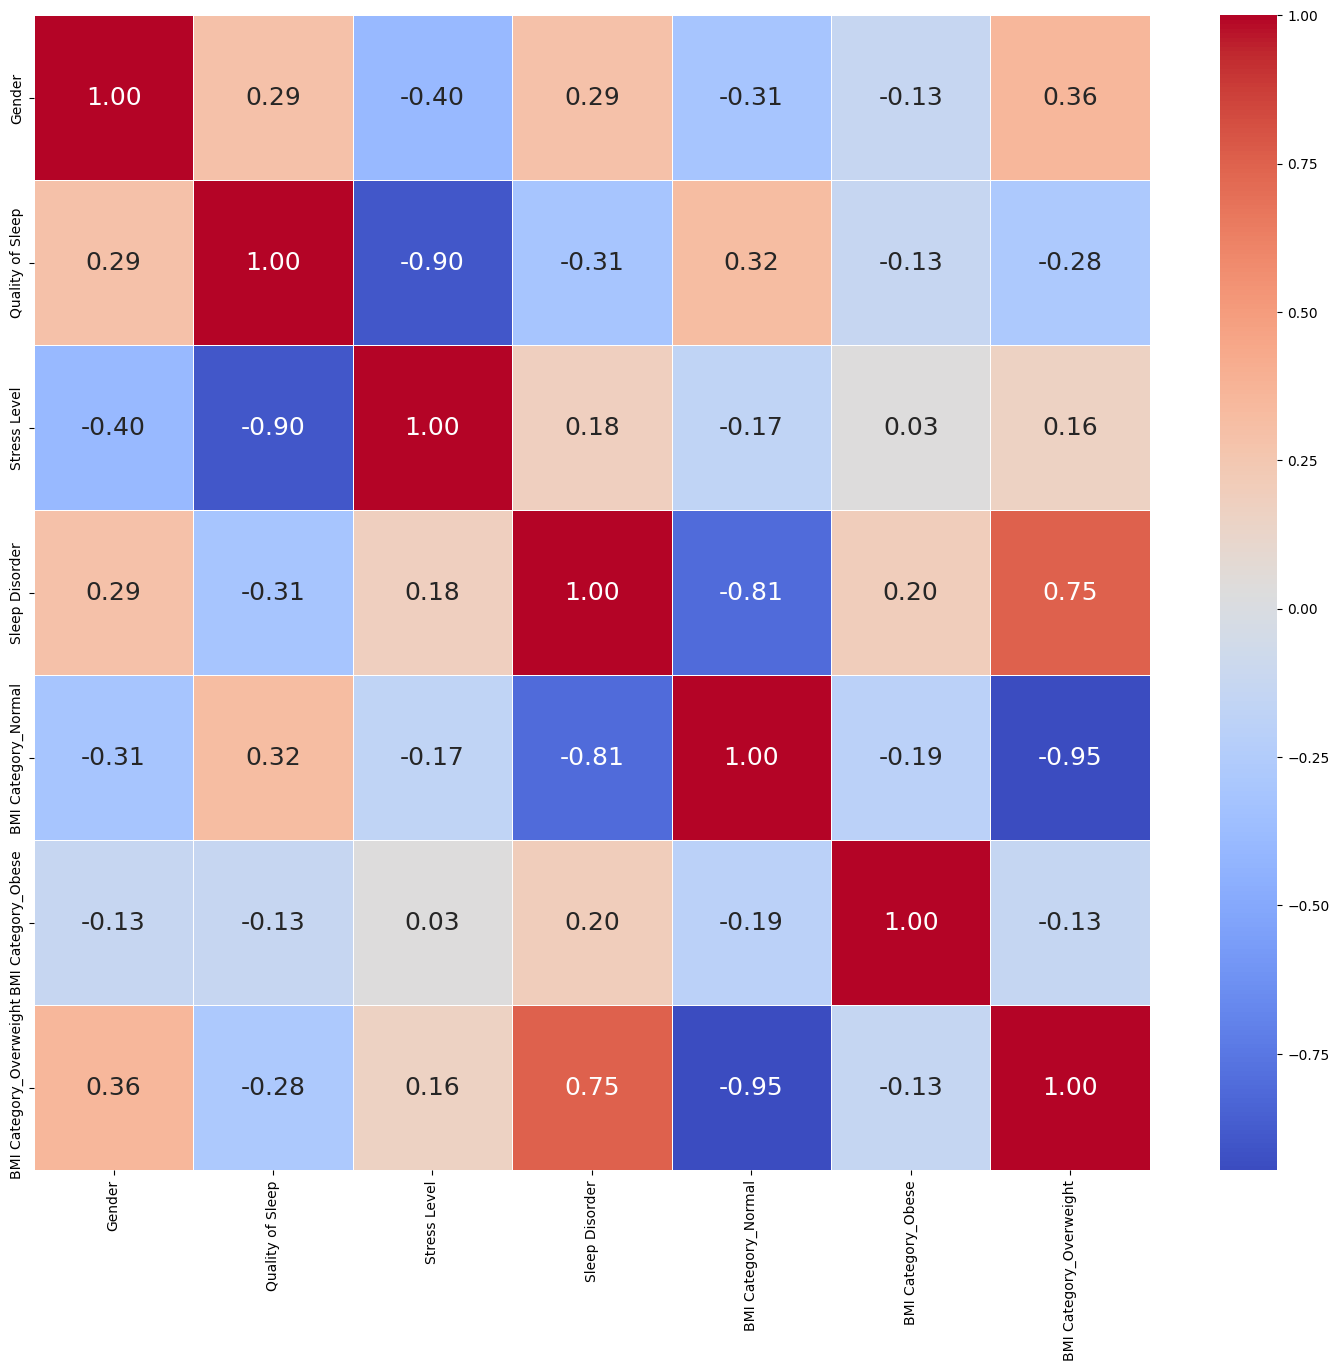

Accuracy Score:  0.92
Confusion Matrix:  [[40  3]
 [ 3 29]]
Classification Report:                precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        43
         1.0       0.91      0.91      0.91        32

    accuracy                           0.92        75
   macro avg       0.92      0.92      0.92        75
weighted avg       0.92      0.92      0.92        75



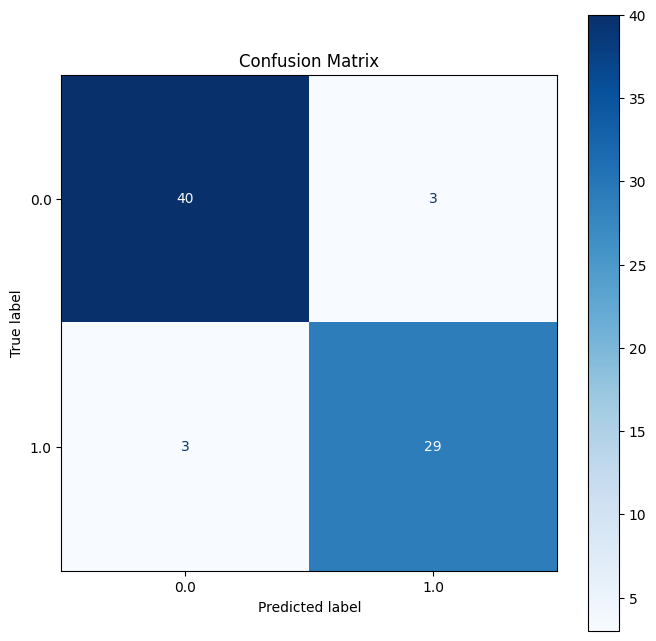

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df_sleep_disorders = df.drop(columns=['Person ID', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'Blood Pressure', 'Heart Rate', 'Daily Steps'])

#stadardize BMI Category values
df_sleep_disorders['BMI Category'] = df_sleep_disorders['BMI Category'].replace('Normal Weight', 'Normal')

#Categorize Quality Of Sleep column into two, converting column to binary

def classify_sleep_quality(quality):
    if 4 <= quality <= 6:
        return 'Low Quality'
    elif 7 <= quality <= 9:
        return 'High Quality'
    else:
        return None

#Categorize Stress Level column into two, converting column to binary

def classify_stress_level(stress):
    if 3 <= stress <= 5:
        return 'Low Stress'
    elif 6 <= stress <= 8:
        return 'High Stress'
    else:
        return None

df_sleep_disorders['Gender'] = df_sleep_disorders['Gender'].replace({'Female': 1, 'Male': 0})
df_sleep_disorders['Sleep Disorder'] = pd.to_numeric(df_sleep_disorders['Sleep Disorder'].replace({'Sleep Apnea': 1, 'Insomnia': 1, 'None': 0}), errors='coerce').fillna(0)
df_sleep_disorders['Quality of Sleep'] = pd.to_numeric(df_sleep_disorders['Quality of Sleep'].replace({'High Quality': 1, 'Low Quality': 0}), errors='coerce')
df_sleep_disorders['Stress Level'] = pd.to_numeric(df_sleep_disorders['Stress Level'].replace({'Low Stress': 1, 'High Stress': 0}), errors='coerce')

#covert to one-hot encoding & concatenate
df_sleep_disorders = pd.get_dummies(df_sleep_disorders, dtype=int)

#plot correlation matrix
correlation_matrix = df_sleep_disorders.corr()

print("\nCorrelation with 'Sleep Disorder':")
print(correlation_matrix['Sleep Disorder'].sort_values(ascending=False))

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, annot_kws={'fontsize': 18})
plt.show()


#Logistic Regression Model
x = df_sleep_disorders[['BMI Category_Normal', 'BMI Category_Obese', 'BMI Category_Overweight', 'Quality of Sleep', 'Stress Level']]
y = df_sleep_disorders['Sleep Disorder']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(x_train, y_train)
preds = model.predict(x_test)
print("Accuracy Score: ", accuracy_score(y_test, preds))
print("Confusion Matrix: ",  confusion_matrix(y_test, preds))
print("Classification Report: ", classification_report(y_test, preds))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()